In [1]:
import pandas as pd

def load_features_from_csv(input_file):
    # Memuat file CSV
    data = pd.read_csv(input_file)

    # Memisahkan fitur (kolom selain label) dan label
    features = data.drop(columns=['label']).values
    labels = data['label'].values

    return features, labels

# Memuat fitur dan label dari file CSV
train_hog_features, train_labels = load_features_from_csv("hog_train_features.csv")
test_hog_features, test_labels = load_features_from_csv("hog_test_features.csv")

# Pastikan fitur dan label dimuat dengan benar
print("Train Features Shape:", train_hog_features.shape)
print("Test Features Shape:", test_hog_features.shape)


Train Features Shape: (2545, 26244)
Test Features Shape: (637, 26244)


In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Menstandarisasi fitur (karena SVM sensitif terhadap skala fitur)
scaler = StandardScaler()
train_hog_features_scaled = scaler.fit_transform(train_hog_features)
test_hog_features_scaled = scaler.transform(test_hog_features)

# Definisikan rentang parameter untuk GridSearchCV
param_grid = {
    'C': [10],
    'kernel': ['rbf']
}

# Inisialisasi model SVM
svc = SVC(probability=True)

# Set up GridSearchCV dengan cross-validation 5-fold
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit grid search pada data training
grid_search.fit(train_hog_features_scaled, train_labels)

# Menampilkan hasil terbaik
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

# Menggunakan model terbaik untuk prediksi pada data testing
best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(test_hog_features_scaled)

# Evaluasi akurasi model
print("Test set accuracy: ", accuracy_score(test_labels, y_pred))


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found:  {'C': 10, 'kernel': 'rbf'}
Best cross-validation score:  0.6440078585461688
Test set accuracy:  0.7268445839874411


Confusion Matrix:
 [[ 97   3  12  15   4]
 [  2 101   6   5   3]
 [ 21  11  69  13  13]
 [  7   2   8  97  12]
 [  5   5   7  20  99]]


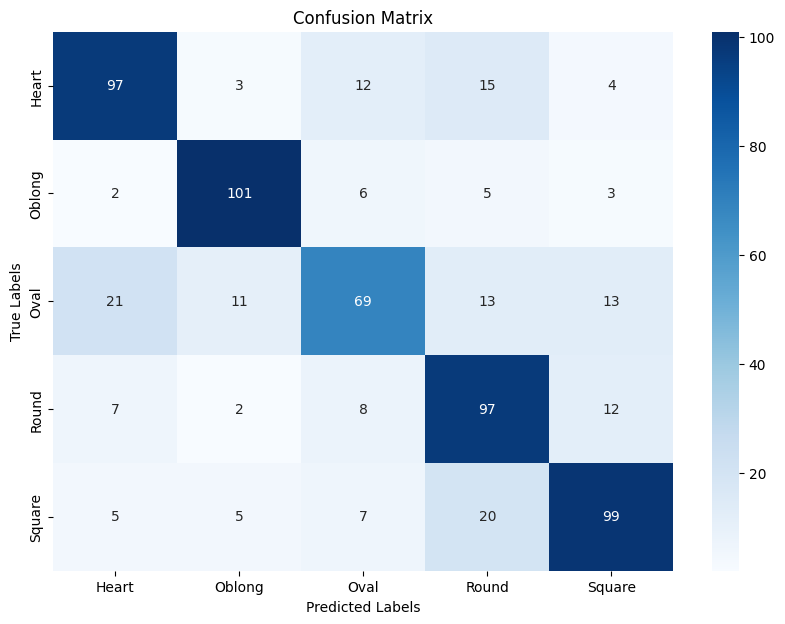

Classification Report:
               precision    recall  f1-score   support

       Heart       0.73      0.74      0.74       131
      Oblong       0.83      0.86      0.85       117
        Oval       0.68      0.54      0.60       127
       Round       0.65      0.77      0.70       126
      Square       0.76      0.73      0.74       136

    accuracy                           0.73       637
   macro avg       0.73      0.73      0.73       637
weighted avg       0.73      0.73      0.72       637



In [3]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat confusion matrix
cm = confusion_matrix(test_labels, y_pred)
print("Confusion Matrix:\n", cm)
# Visualisasi confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_svc.classes_, yticklabels=best_svc.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Laporan klasifikasi
print("Classification Report:\n", classification_report(test_labels, y_pred))

In [4]:
import joblib
# Simpan model ke file
joblib.dump(best_svc, 'hog_model.pkl')

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [5]:
import joblib

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_hog_features)  # Fit dan transform data training

# Simpan scaler ke file
joblib.dump(scaler, 'scaler_hog.pkl')

['scaler_hog.pkl']